In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
chemin_final = r"C:\\Users\\zizou\\OneDrive\\Desktop\\stage 3ème\\day 2\\csvfiles\\dataframefinale.csv"
df = pd.read_csv(chemin_final, sep=';', encoding='utf-8-sig')
df

,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,01/07/2025,TN0008000739,"BTA 7,4% Fevrier 2030",1459.0,1.500,62.0,7.60
1,01/07/2025,TN0008000739,"BTA 7,4% Fevrier 2030",291.0,0.300,183.0,7.50
2,01/07/2025,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50000.0,5.000,13.0,8.60
3,01/07/2025,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10000.0,1.000,7.0,8.60
4,01/07/2025,TN0008000606,"BTA 6,7% Avril 2028",5660.0,5.742,31.0,9.10
...,...,...,...,...,...,...,...
19954,31/12/2024,TN0008000812,"BTA 7,5% 13/12/2028",215.0,0.200,50.0,9.00
19955,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,5243.0,0.556,15.0,7.49
19956,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,28288.0,3.000,31.0,8.99
19957,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,48701.0,5.165,31.0,8.99


In [4]:
df.describe()

,Nombre de Titres,Montant,Echéance,Taux
count,19959.000000,19959.000000,19959.000000,19959.000000
mean,9026.238589,4.911538,40.139085,8.625515
std,18104.927320,8.206792,61.145092,0.813750
min,1.000000,0.001000,0.000000,5.800000
25%,1073.500000,1.000000,10.000000,8.030000
50%,3132.000000,2.001000,21.000000,8.970000
75%,8778.000000,5.500000,32.000000,9.010000
max,371911.000000,120.000000,365.000000,10.750000


In [5]:
# === CELLULE 4 : Nombre d'outliers AVANT Winsorisation ===
def detect_outliers(df, col, lower_quantile=0.01, upper_quantile=0.99):
    q_low = df[col].quantile(lower_quantile)
    q_high = df[col].quantile(upper_quantile)
    return df[(df[col] < q_low) | (df[col] > q_high)]

colonnes_numeriques = ["Nombre de Titres", "Montant", "Echéance", "Taux"]
outliers_avant = {}
for col in colonnes_numeriques:
    outliers = detect_outliers(df, col)
    outliers_avant[col] = len(outliers)

print("\n📊 Nombre d'outliers AVANT Winsorisation :")
for k, v in outliers_avant.items():
    print(f"{k}: {v} outliers")


📊 Nombre d'outliers AVANT Winsorisation :
Nombre de Titres: 398 outliers
Montant: 385 outliers
Echéance: 265 outliers
Taux: 331 outliers


In [29]:
def corriger_outliers_winsorisation(df, colonnes, lower_quantile=0.01, upper_quantile=0.99):
    for col in colonnes:
        q_low = df[col].quantile(lower_quantile)
        q_high = df[col].quantile(upper_quantile)
        df[col] = df[col].clip(lower=q_low, upper=q_high)
    return df

df_corrige = df.copy()
df_corrige = corriger_outliers_winsorisation(df_corrige, colonnes_numeriques)


In [30]:
outliers_apres = {}
for col in colonnes_numeriques:
    outliers = detect_outliers(df_corrige, col)
    outliers_apres[col] = len(outliers)

print("\n📉 Nombre d'outliers APRÈS correction par Winsorisation :")
for k, v in outliers_apres.items():
    print(f"{k}: {v} outliers")


📉 Nombre d'outliers APRÈS correction par Winsorisation :
Nombre de Titres: 0 outliers
Montant: 0 outliers
Echéance: 0 outliers
Taux: 0 outliers


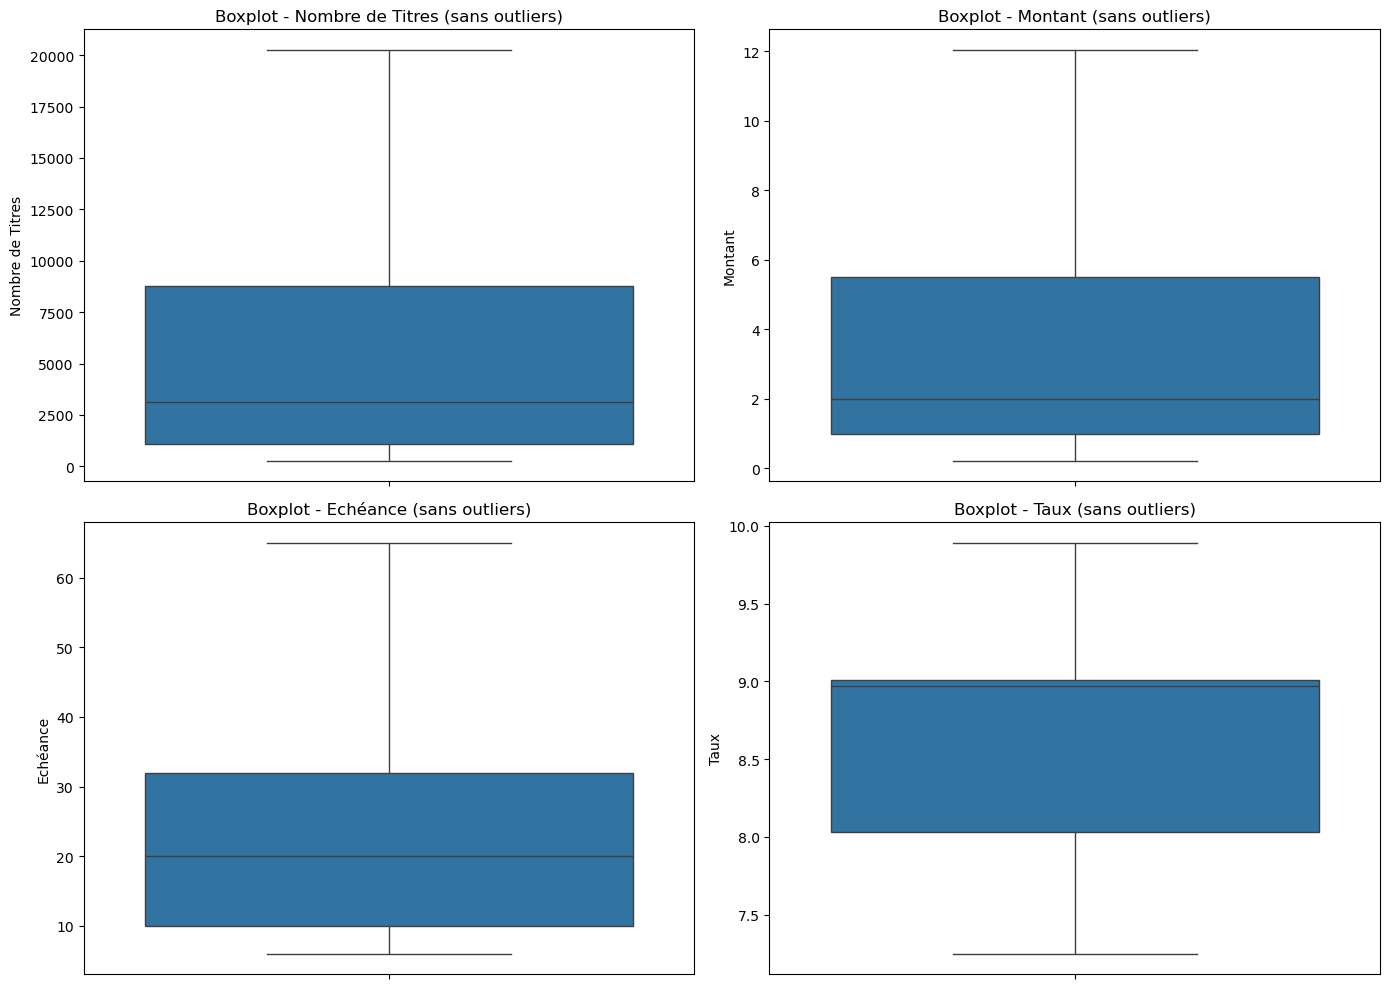

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(colonnes_numeriques):
    sns.boxplot(data=df_corrige, y=col, ax=axes[i], showfliers=False)
    axes[i].set_title(f"Boxplot - {col} (sans outliers)")
plt.tight_layout()
plt.show()


In [22]:
print("\n📐 Intervalles centrés (1% - 99%) pour chaque variable :")
for col in colonnes_numeriques:
    low = df[col].quantile(0.01)
    high = df[col].quantile(0.99)
    print(f"{col} : [{low:.2f} ; {high:.2f}]")



📐 Intervalles centrés (1% - 99%) pour chaque variable :
Nombre de Titres : [86.00 ; 89653.96]
Montant : [0.08 ; 42.44]
Echéance : [3.00 ; 347.00]
Taux : [6.69 ; 10.05]
